## Dataset

In [1]:
# Torchvision, PyTorch çerçevesindeki (framework) bir kütüphanedir (library).
# datasets hazır (MNIST, CIFAR10 vb.) veri setlerine sağlayan bir modül.
# transforms ise veriyi modüle uygun hale getirmek için kullandığımız modüldür. 
# DataLoader ise veriyi model için uygun hale getireceğimiz bir sınıftır.
from torchvision import datasets, transforms 
from torch.utils.data import DataLoader

In [2]:
transform = transforms.Compose([ #Pipeline
    transforms.Pad(2), # Görüntü etrafına 2 piksellik padding eklenir. 
    transforms.ToTensor(), # Görüntü PyTorch tensör formatına çevrilir. 
    transforms.Normalize((0.5,), (0.5,)) # Ortalama ve standart sapma ile normalize eder.
])

train_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_data = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 476kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.27MB/s]


In [3]:
print("nums of train:", len(train_data))
print("nums of test:", len(test_data))

nums of train: 60000
nums of test: 10000


In [4]:
image, label = train_data[0]
print("Shape of img:", image.shape)  # örn: torch.Size([1, 32, 32])
print("Label:", label)
print("Type:", type(image))

Shape of img: torch.Size([1, 32, 32])
Label: 5
Type: <class 'torch.Tensor'>


In [5]:
image[0,1,1]

tensor(-1.)

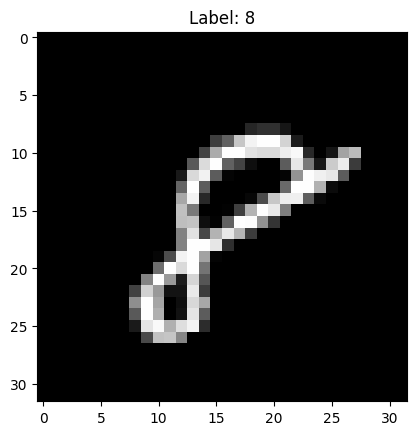

In [6]:
import matplotlib.pyplot as plt

image, label = train_data[59999]
plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"Label: {label}")
plt.show()

In [7]:
print(image.size(0))
print(image.size(1))
print(image.size(2))

1
32
32


## Model (LeNet-5)

In [8]:
# Reference: https://github.com/activatedgeek/LeNet-5
import torch.nn as nn # Katmanlar, aktivasyon fonksiyonları, loss fonksiyonları.
from collections import OrderedDict # Katmanları daha verimli tanımlama için kullanılan bir sınıf import edilir.

class C1(nn.Module): ## nn.Module bir base class
    def __init__(self):
        super(C1,self).__init__()

        self.c1 = nn.Sequential(OrderedDict([
            ("c1",nn.Conv2d(1, 6, kernel_size=(5,5))),
            ("relu1",nn.ReLU()),
            ("s1",nn.MaxPool2d(kernel_size =(2,2), stride = 2))
        ]))
    def forward(self, img):
        output = self.c1(img)
        return output


class C2(nn.Module):
    def __init__(self):
        super(C2, self).__init__()

        self.c2 = nn.Sequential(OrderedDict([
            ('c2', nn.Conv2d(6, 16, kernel_size=(5, 5))),
            ('relu2', nn.ReLU()),
            ('s2', nn.MaxPool2d(kernel_size=(2, 2), stride=2))
        ]))

    def forward(self, img):
        output = self.c2(img)
        return output


class C3(nn.Module):
    def __init__(self):
        super(C3, self).__init__()

        self.c3 = nn.Sequential(OrderedDict([
            ('c3', nn.Conv2d(16, 120, kernel_size=(5, 5))),
            ('relu3', nn.ReLU())
        ]))

    def forward(self, img):
        output = self.c3(img)
        return output


class F4(nn.Module):
    def __init__(self):
        super(F4, self).__init__()

        self.f4 = nn.Sequential(OrderedDict([
            ('f4', nn.Linear(120, 84)),
            ('relu4', nn.ReLU())
        ]))

    def forward(self, img):
        output = self.f4(img)
        return output


class F5(nn.Module):
    def __init__(self):
        super(F5, self).__init__()

        self.f5 = nn.Sequential(OrderedDict([
            ("f5", nn.Linear(84,10)),
            ("sig5", nn.LogSoftmax(dim=-1))
        ]))
        
    def forward(self,img):
        output = self.f5(img)
        return output

class LeNet5(nn.Module):
    """
    Input - 1x32x32
    Output - 10
    """
    def __init__(self):
        super(LeNet5, self).__init__()

        self.c1 = C1()
        self.c2_1 = C2() 
        self.c2_2 = C2() 
        self.c3 = C3() 
        self.f4 = F4() 
        self.f5 = F5() 

    def forward(self, img):
        output = self.c1(img)

        x = self.c2_1(output)
        output = self.c2_2(output)
        
        output += x
        
        output = self.c3(output)
        output = output.view(img.size(0), -1)
        output = self.f4(output)
        output = self.f5(output)
        return output

In [9]:
import torch

x2 = torch.randn(2, 3, 4, 5) # Batch size, Channel, Heigth, Width
x2

tensor([[[[-0.5642,  1.0383, -1.0318, -0.3132,  1.2665],
          [-0.3201, -2.0200, -1.1447,  0.1661,  0.0887],
          [-0.4420,  0.6942, -0.9057, -0.2912, -1.0755],
          [-2.6426, -0.2303, -0.8662, -0.4021, -0.5243]],

         [[ 0.3806,  0.4267,  0.9575, -0.5498, -0.0314],
          [-0.5250,  0.6175, -0.1515,  0.1233,  0.8140],
          [ 0.8560, -1.3229,  2.0087, -1.2873,  0.5698],
          [ 0.3752,  0.6038,  0.3838, -0.9394, -0.1401]],

         [[-0.9892,  0.3351,  0.4984,  0.0248, -1.7283],
          [-0.4004,  0.7725, -0.4807, -1.1227,  0.4932],
          [ 0.2696, -0.2108,  0.0439, -0.2367, -1.7049],
          [-0.0907, -0.4746,  0.2990,  1.0037, -0.4175]]],


        [[[-2.0464,  1.2013, -1.2554, -0.4235, -2.0948],
          [-0.0696, -0.2040, -0.7207,  0.6794, -0.0222],
          [ 0.5510,  2.0609, -1.0099,  0.2577, -0.5579],
          [ 0.3880,  0.3970, -0.6852, -0.2113,  1.1387]],

         [[ 0.0815, -1.1321,  0.2489,  1.1684,  0.0896],
          [-2.0727,  

In [10]:
# Katmanları oluştur
c1 = C1()
c2_1 = C2()
c2_2 = C2()
c3 = C3()

# Input (batch=64)
x = torch.randn(64, 1, 32, 32)

print("Input:", x.shape)

# C1
x = c1(x)
print("After C1:", x.shape)

# C2 (residual yapı)
x1 = c2_1(x)
print("After C2_1:", x1.shape)

x2 = c2_2(x)
print("After C2_2:", x2.shape)

x = x1 + x2
print("After residual sum:", x.shape)

# C3
x = c3(x)
print("After C3:", x.shape)

# Flatten
x = x.view(x.size(0), -1)
print("After flatten:", x.shape)

Input: torch.Size([64, 1, 32, 32])
After C1: torch.Size([64, 6, 14, 14])
After C2_1: torch.Size([64, 16, 5, 5])
After C2_2: torch.Size([64, 16, 5, 5])
After residual sum: torch.Size([64, 16, 5, 5])
After C3: torch.Size([64, 120, 1, 1])
After flatten: torch.Size([64, 120])


In [11]:
x2

tensor([[[[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 2.3167e-02, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 5.9737e-02]],

         [[0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 1.1608e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00],
          [0.0000e+00, 0.0000e+00, 2.4689e-01, 2.7076e-01, 1.6446e-01],
          [0.0000e+00, 1.5367e-01, 1.7838e-01, 2.7275e-01, 0.0000e+00],
          [0.0000e+00, 2.4378e-01, 0.0000e+00, 0.0000e+00, 0.0000e+00]],

         [[4.5865e-01, 7.2254e-01, 2.3261e-01, 4.4485e-01, 6.9342e-01],
          [3.9820e-01, 6.8302e-01, 6.4136e-01, 6.1100e-01, 3.4284e-01],
          [5.0873e-01, 5.3598e-01, 4.6560e-01, 2.9163e-01, 5.6244e-01],
          [5.8180e-02, 6.2619e-01, 6.9545e-01, 4.6132e-01, 9

## Model Train on Train Dataset

In [12]:
import torch
import torch.optim as optim
model = LeNet5()
model2 = LeNet5()

In [13]:
for name, param in model.named_parameters(): 
    print(f"Parametre adı: {name}")
    print(f"Şekli: {param.shape}") # [out_channels, in_channels, kernel_height, kernel_width]
    print(f"Değerler:\n{param}")
    print("-----------")

Parametre adı: c1.c1.c1.weight
Şekli: torch.Size([6, 1, 5, 5])
Değerler:
Parameter containing:
tensor([[[[ 0.1873,  0.1863,  0.1011, -0.1331,  0.1220],
          [ 0.0159,  0.0631, -0.1831, -0.0965,  0.0735],
          [-0.0110, -0.0120, -0.0564, -0.0581,  0.1766],
          [ 0.0194,  0.1569, -0.0960, -0.0106, -0.0608],
          [-0.1231, -0.1731,  0.0372,  0.1004, -0.0701]]],


        [[[ 0.1595,  0.0373,  0.0133,  0.0174,  0.0495],
          [-0.0488,  0.1063, -0.1428, -0.1577,  0.1839],
          [-0.1200,  0.1004, -0.1139, -0.0014,  0.0373],
          [-0.1292,  0.0555,  0.1585,  0.1900,  0.1093],
          [ 0.0271, -0.0424,  0.0957, -0.1407,  0.1573]]],


        [[[ 0.1344, -0.0511,  0.1649,  0.1831,  0.1997],
          [-0.1910, -0.0498, -0.0550,  0.0925,  0.1104],
          [ 0.0072,  0.1387,  0.0451, -0.0380, -0.1714],
          [-0.1883, -0.0661, -0.0148, -0.0349, -0.0370],
          [-0.0136,  0.1301, -0.0857, -0.0459,  0.0650]]],


        [[[-0.1239,  0.1609, -0.0565, 

In [14]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)
for epoch in range(2):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"epoch = {epoch} loss = {running_loss/len(train_loader)}")

epoch = 0 loss = 0.16990856286103545
epoch = 1 loss = 0.0892476393012896


## Model Test on Test Dataset

In [15]:
model.eval()

correct_1 = 0
total = 0

with torch.no_grad():  
    for images, labels in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct_1 += (predicted == labels).sum().item()

accuracy = 100 * correct_1 / total
print(f'Test Accuracy: {accuracy:.2f}%')

Test Accuracy: 97.50%


In [16]:
# We have NOT trained the model2 so it should give poor results (random results around 1/10 by the homogeneous random distribution)
model2.eval()

correct_2 = 0
total = 0

with torch.no_grad():  
    for images, labels in test_loader:
        outputs = model2(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct_2 += (predicted == labels).sum().item()

accuracy = 100 * correct_2 / total
print(f'Test Accuracy: {accuracy:.2f}%')

Test Accuracy: 10.10%


In [17]:
correct_1

9750

In [18]:
correct_2

1010


# The first section was already written in the last laboratory session. 

# Now, we aim to create another CNN model from zero (with pytorch ofc) but this time we aim to add extra layers like dropout, batch normalization layer(s).


In [19]:
class LeNet5Modified(nn.Module):
    """
    Input - 1x32x32
    Output - 10
    """
    def __init__(self, dropout_rate = 0.15):
        super(LeNet5Modified, self).__init__()

        self.c1 = C1()
        self.c2_1 = C2() 
        self.c2_2 = C2() 
        self.c3 = C3() 
        self.f4 = F4() 
        self.f5 = F5() 

        # Normalization layers 
        self.bn_c1 = nn.BatchNorm2d(num_features=6)   # fill with output channels of C1
        self.bn_c2 = nn.BatchNorm2d(num_features=16)   # output channels of C2
        self.bn_c3 = nn.BatchNorm2d(num_features=120)   # output channels of C3
        
        # Dropout layer 
        self.dropout = nn.Dropout(p=dropout_rate)
        
    def forward(self, img):
        
        output = self.c1(img)
        output = self.bn_c1(output)

        
        # Residual‑like connection
        x = self.c2_1(output)
        x = self.bn_c2(x)
        output = self.c2_2(output)
        output = self.bn_c2(output)
        output += x
        
        # C3 -> BN
        output = self.c3(output)
        output = self.bn_c3(output)

        output = output.view(img.size(0), -1)
        output = self.f4(output)
        output = self.dropout(output) # hidden layer
        output = self.f5(output)
        return output

In [20]:
model3 = LeNet5Modified()

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model3.parameters(), lr=0.01)
for epoch in range(2):
    running_loss = 0.0
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model3(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"epoch = {epoch} loss = {running_loss/len(train_loader)}")

epoch = 0 loss = 0.1312545195393421
epoch = 1 loss = 0.06822975217362247


In [22]:
model3.eval()

correct_3 = 0
total = 0

with torch.no_grad():  
    for images, labels in test_loader:
        outputs = model3(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct_3 += (predicted == labels).sum().item()

accuracy = 100 * correct_3 / total
print(f'Test Accuracy: {accuracy:.2f}%')

Test Accuracy: 96.74%


In [ ]:
# This prints the name and the actual matrix of numbers for each layer
for name, param in model3.named_parameters():
    print(f"Layer: {name} | Size: {param.size()}")
    print(param.data) # These are the actual numbers the AI learns

# MODEL4: How are the popular pretrained models performing on the MINST dataset ?

In [24]:
from torchvision import models

# We are importing the VGG11 model
# pretrained=False, we try first without transfer learning
model_vgg = models.vgg11(pretrained=False)

# 1. Changement input channel to 1 because MINST is black and white
model_vgg.features[0] = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1)

# 2. Changement: NN output to 10 because we have 10 labels.
model_vgg.classifier[6] = nn.Linear(4096, 10)

# Model GPU/CPU 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vgg.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


VGG(
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (11): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (12): ReLU(inplace=True)
    (13): Conv2d(512, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (14): ReLU(inplace=True)
    (15): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
 

In [25]:
criterion = nn.CrossEntropyLoss() # same loss and optimizer functions with other models
optimizer = optim.Adam(model_vgg.parameters(), lr=0.001)

print("VGG11 Traning Starting...")

for epoch in range(2): # Same epoch number so we can do a true comparison with other models
    running_loss = 0.0
    model_vgg.train()
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model_vgg(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch} - Loss: {running_loss/len(train_loader):.4f}")

VGG11 Traning Starting...
Epoch 0 - Loss: 0.5358
Epoch 1 - Loss: 0.1235


In [26]:
model_vgg.eval()
correct_vgg = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_vgg(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct_vgg += (predicted == labels).sum().item()

accuracy_vgg = 100 * correct_vgg / total
print(f'VGG11 MNIST Test Accuracy: {accuracy_vgg:.2f}%')

VGG11 MNIST Test Accuracy: 98.51%


In [27]:
# LETS TRY WITH TRANSFER LEARNING THIS TIME !!!, pre_trained = True !!
# pre_trained is deprecated so we upload weights instead

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models

# 1. Load the pre-trained model into a NEW variable
model_vgg_tl = models.vgg11(weights=models.VGG11_Weights.DEFAULT)

# 2. Freeze the pre-trained feature layers
for param in model_vgg_tl.features.parameters():
    param.requires_grad = False

# 3. Change input channel to 1 (MNIST is black and white)
model_vgg_tl.features[0] = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1)

# 4. Change NN output to 10 (10 labels)
model_vgg_tl.classifier[6] = nn.Linear(4096, 10)

# Model GPU/CPU 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_vgg_tl.to(device) 

criterion = nn.CrossEntropyLoss() 

# 5. Update Optimizer to only track the new model's unfrozen parameters
optimizer_tl = optim.Adam(filter(lambda p: p.requires_grad, model_vgg_tl.parameters()), lr=0.001)

print("VGG11 Transfer Learning Training Starting...")

for epoch in range(2): 
    running_loss = 0.0
    model_vgg_tl.train()
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer_tl.zero_grad()
        outputs = model_vgg_tl(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer_tl.step()
        
        running_loss += loss.item()
    
    print(f"Epoch {epoch} - TL Loss: {running_loss/len(train_loader):.4f}") 

# Evaluation Phase
model_vgg_tl.eval()
correct_vgg_tl = 0
total_tl = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model_vgg_tl(images)
        _, predicted = torch.max(outputs.data, 1)
        total_tl += labels.size(0)
        correct_vgg_tl += (predicted == labels).sum().item()

accuracy_vgg_tl = 100 * correct_vgg_tl / total_tl
print(f'VGG11 Transfer Learning MNIST Test Accuracy: {accuracy_vgg_tl:.2f}%')


Downloading: "https://download.pytorch.org/models/vgg11-8a719046.pth" to /root/.cache/torch/hub/checkpoints/vgg11-8a719046.pth


100%|██████████| 507M/507M [00:02<00:00, 235MB/s] 


VGG11 Transfer Learning Training Starting...
Epoch 0 - TL Loss: 0.6773
Epoch 1 - TL Loss: 0.4028
VGG11 Transfer Learning MNIST Test Accuracy: 93.67%


# Now, we use CNN's self feature extractor and pass the output thorugh a ML model. This is one of the popular use case of CNN's

In [30]:
import numpy as np
from sklearn.metrics import accuracy_score
from cuml.ensemble import RandomForestClassifier as cuRF
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Preparing the Feature Extractor Model
# Using weights=None in modern PyTorch initializes the model with random weights
vgg_extractor = models.vgg11(weights=None)

# Change the first layer to 1 channel since MNIST is grayscale (black and white)
vgg_extractor.features[0] = nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1)

vgg_extractor.classifier[6] = nn.Identity()

vgg_extractor.to(device)
vgg_extractor.eval() # Set model to evaluation mode 

# Helper Function for Feature Extraction
def extract_features(dataloader, model):
    features = []
    labels = []
    
    with torch.no_grad(): # No need to calculate gradients, just forward pass
        for images, targets in dataloader:
            images = images.to(device)
            
            # Get the 4096-dimensional features from the model
            outputs = model(images)
            
            # Move tensors to CPU and convert to numpy arrays
            features.append(outputs.cpu().numpy())
            labels.append(targets.numpy())
            
    # Stack the list of numpy arrays into a single large matrix
    return np.vstack(features), np.concatenate(labels)

print("Extracting Training Set")
X_train, y_train = extract_features(train_loader, vgg_extractor)

print("Extracting Test Set")
X_test, y_test = extract_features(test_loader, vgg_extractor)

#Explicitly printing the dimensions and lengths of the datasets
print("\n--- Extracted Dataset Dimensions ---")
print(f"Train Features Shape : {X_train.shape} | Total Samples: {len(X_train)}")
print(f"Train Labels Shape   : {y_train.shape} | Total Samples: {len(y_train)}")
print(f"Test Features Shape  : {X_test.shape} | Total Samples: {len(X_test)}")
print(f"Test Labels Shape    : {y_test.shape} | Total Samples: {len(y_test)}")
print("------------------------------------\n")

# Saving Features and Labels in .npy Format
# Renamed the files slightly to indicate they come from an untrained model
np.save("vgg11_untrained_features_train.npy", X_train)
np.save("vgg11_untrained_labels_train.npy", y_train)
np.save("vgg11_untrained_features_test.npy", X_test)
np.save("vgg11_untrained_labels_test.npy", y_test)
print("Features and labels successfully saved as '.npy' files.\n")

# Training and Testing with a Canonical Machine Learning Model (Random Forest)
print("Training the Canonical Machine Learning Model (Random Forest)...")
ml_model = cuRF(n_estimators=100, random_state=42)

# Train the model using the extracted random features
ml_model.fit(X_train, y_train)

# Make predictions on the test set
print("Making predictions on the test set...")
y_pred = ml_model.predict(X_test)

# Evaluate the results
accuracy_hybrid = accuracy_score(y_test, y_pred) * 100
print(f"\nHybrid Model (Untrained VGG11 + Random Forest) Test Accuracy: {accuracy_hybrid:.2f}%")

Extracting Training Set
Extracting Test Set

--- Extracted Dataset Dimensions ---
Train Features Shape : (60000, 4096) | Total Samples: 60000
Train Labels Shape   : (60000,) | Total Samples: 60000
Test Features Shape  : (10000, 4096) | Total Samples: 10000
Test Labels Shape    : (10000,) | Total Samples: 10000
------------------------------------

Features and labels successfully saved as '.npy' files.

Training the Canonical Machine Learning Model (Random Forest)...
Making predictions on the test set...

Hybrid Model (Untrained VGG11 + Random Forest) Test Accuracy: 91.01%


# FINAL COMPARISON TABLE

In [34]:
import pandas as pd

# 1. Re-calculate the LeNet accuracies on the fly 
# (Since the generic 'accuracy' variable was overwritten multiple times in your notebook)
accuracy_lenet = 100 * correct_1 / total
accuracy_lenet_untrained = 100 * correct_2 / total
accuracy_lenet_mod = 100 * correct_3 / total

model_names = [
    "VGG11 (Trained from scratch)",
    "LeNet-5 (Trained)",
    "LeNet-5 Modified (BatchNorm + Dropout)",
    "VGG11 (Transfer Learning)",
    "Hybrid (Untrained VGG11 + Random Forest)",
    "LeNet-5 (Untrained)"
]

test_accuracies = [
    accuracy_vgg,                # From your VGG11 block
    accuracy_lenet,              # From correct_1
    accuracy_lenet_mod,          # From correct_3
    accuracy_vgg_tl,             # From your VGG11 Transfer Learning block
    accuracy_hybrid,             # From your cuRF Hybrid block
    accuracy_lenet_untrained     # From correct_2
]

results_dict = {
    "Model Architecture & State": model_names,
    "Test Accuracy (%)": test_accuracies
}
df_results = pd.DataFrame(results_dict)

df_results = df_results.sort_values(by="Test Accuracy (%)", ascending=False).reset_index(drop=True)
df_results.index = df_results.index + 1
df_results.index.name = 'Rank'

# Print the final comparison table
print("--- Test Accuracies of Models on the MNIST Dataset ---")
df_results

--- Test Accuracies of Models on the MNIST Dataset ---


,Model Architecture & State,Test Accuracy (%)
Rank,,
1,VGG11 (Trained from scratch),98.51
2,LeNet-5 (Trained),97.50
3,LeNet-5 Modified (BatchNorm + Dropout),96.74
4,VGG11 (Transfer Learning),93.67
5,Hybrid (Untrained VGG11 + Random Forest),91.01
6,LeNet-5 (Untrained),10.10
